# Baselines, backtest and the LightGBM model

The methodology, not the model, is the point. We forecast load 1–48h ahead and ask a
single question: **how much does a learned model actually beat honest baselines?**

- **Baselines.** Daily persistence (same hour, previous whole day) and seasonal-naive
  (same hour, previous week). Load has strong weekly structure, so seasonal-naive is a
  genuinely strong baseline.
- **Evaluation.** A **rolling-origin backtest**, never a random split. LightGBM is
  retrained monthly on a rolling two-year window and scored on the following month; the
  baselines are scored on exactly the same timestamps.
- **Direct multi-horizon.** One model per horizon, predicting `y(t+h)` from features
  known at `t`. Weather enters as the temperature at the target hour (a documented
  perfect-forecast proxy); price and mix enter only as lags.

Results here are read from the cached backtest (`python -m src.evaluate`).

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config, features, model

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 4)

df = pd.read_parquet(config.DATASET_PARQUET)
metrics = pd.read_csv(config.PROCESSED / "backtest_metrics.csv")
preds = pd.read_parquet(config.BACKTEST_PARQUET)
metrics

,horizon,model,MAE,MAPE,RMSE,MAE_vs_seasonal_%
0,1,lightgbm,481.681038,0.916013,644.145418,81.5
1,1,naive,3952.942178,7.542790,5925.544171,-51.7
2,1,seasonal_naive,2605.084518,4.991930,4055.374784,0.0
3,6,lightgbm,1229.449130,2.342065,1643.577477,52.8
4,6,naive,3953.016264,7.543044,5925.559376,-51.8
5,6,seasonal_naive,2604.089732,4.989959,4053.958019,0.0
6,12,lightgbm,1397.538155,2.656628,1863.075781,46.3
7,12,naive,3951.296310,7.539987,5923.648610,-51.9
8,12,seasonal_naive,2601.873945,4.986084,4049.528447,0.0
9,24,lightgbm,1395.057079,2.665304,1875.840524,46.3


## Metrics vs. baselines, per horizon
MAE and MAPE for each horizon; the last column is LightGBM's MAE reduction over seasonal-naive.

In [2]:
view = metrics.pivot(index="horizon", columns="model", values="MAE").round(0)
view.columns = [f"MAE_{c}" for c in view.columns]
mape = metrics.pivot(index="horizon", columns="model", values="MAPE").round(2)
view["MAPE_lightgbm"] = mape["lightgbm"]
view["MAE_reduction_%"] = metrics[metrics.model == "lightgbm"].set_index("horizon")["MAE_vs_seasonal_%"]
view

,MAE_lightgbm,MAE_naive,MAE_seasonal_naive,MAPE_lightgbm,MAE_reduction_%
horizon,,,,,
1,482.0,3953.0,2605.0,0.92,81.5
6,1229.0,3953.0,2604.0,2.34,52.8
12,1398.0,3951.0,2602.0,2.66,46.3
24,1395.0,3950.0,2598.0,2.67,46.3
48,1665.0,6390.0,2595.0,3.17,35.8


## Error by horizon
As the horizon grows the model keeps its edge over both baselines. This figure is reused in the README.

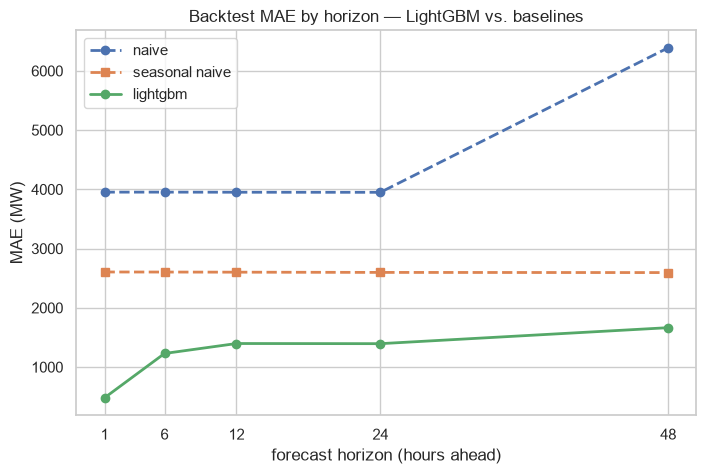

In [3]:
curve = metrics.pivot(index="horizon", columns="model", values="MAE")
fig, ax = plt.subplots(figsize=(8, 5))
for col, style in [("naive","o--"), ("seasonal_naive","s--"), ("lightgbm","o-")]:
    ax.plot(curve.index, curve[col], style, label=col.replace("_"," "), lw=2)
ax.set(xlabel="forecast horizon (hours ahead)", ylabel="MAE (MW)",
       title="Backtest MAE by horizon — LightGBM vs. baselines")
ax.set_xticks(curve.index); ax.legend()
reports = config.ROOT / "reports"; reports.mkdir(exist_ok=True)
fig.savefig(reports / "error_by_horizon.png", dpi=110, bbox_inches="tight")
plt.show()

## Forecast vs. actual
A two-week window at the 24h horizon: LightGBM tracks the daily peaks the seasonal-naive baseline systematically misses.

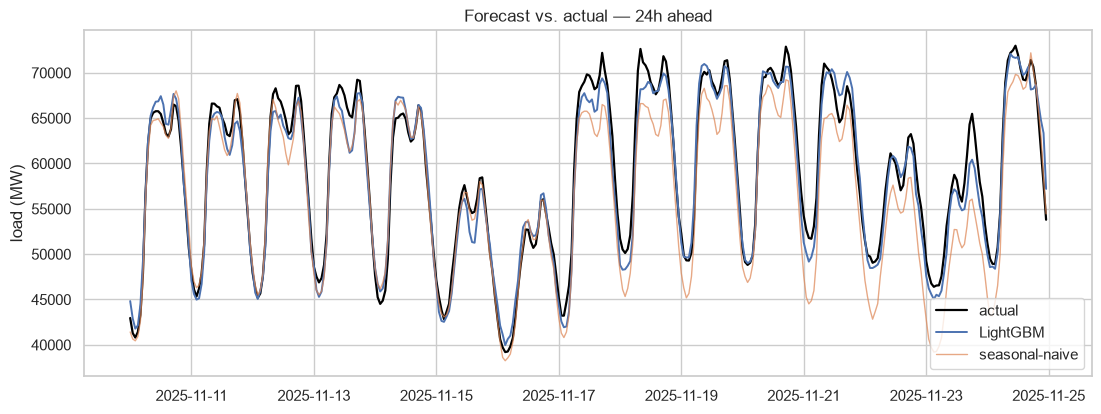

In [4]:
h = 24
hz = preds[preds.horizon == h].sort_index()
win = hz.loc["2025-11-10":"2025-11-24"]
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(win.index, win.y_true, label="actual", color="black", lw=1.6)
ax.plot(win.index, win.lightgbm, label="LightGBM", lw=1.4)
ax.plot(win.index, win.seasonal_naive, label="seasonal-naive", lw=1.0, alpha=0.7)
ax.set(ylabel="load (MW)", title=f"Forecast vs. actual — {h}h ahead"); ax.legend()
plt.show()

## Where does the model win and lose?
Residuals broken down by hour of day, holiday flag and temperature. Errors concentrate at the morning/evening ramps and on holidays — the hard, non-routine hours.

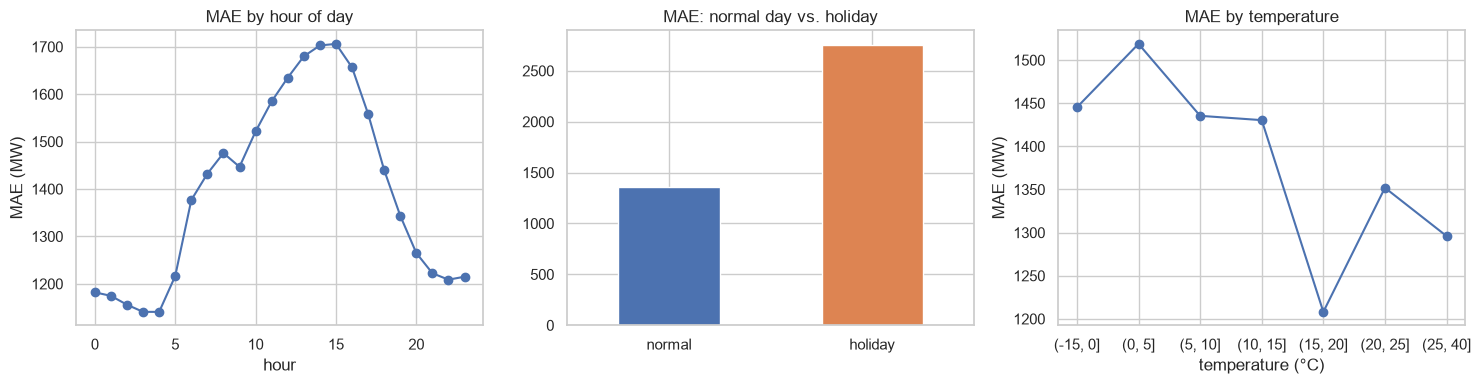

In [5]:
import holidays
h = 24
hz = preds[preds.horizon == h].copy()
hz["abs_err"] = (hz.y_true - hz.lightgbm).abs()
hz["hour"] = hz.index.hour
de = holidays.Germany()
hz["is_holiday"] = [d.date() in de for d in hz.index]
hz = hz.join(df["temp_DE"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
hz.groupby("hour")["abs_err"].mean().plot(ax=axes[0], marker="o")
axes[0].set(title="MAE by hour of day", xlabel="hour", ylabel="MAE (MW)")
hz.groupby("is_holiday")["abs_err"].mean().plot.bar(ax=axes[1], rot=0, color=["#4c72b0","#dd8452"])
axes[1].set(title="MAE: normal day vs. holiday", xlabel="")
axes[1].set_xticklabels(["normal","holiday"])
tbin = pd.cut(hz["temp_DE"], bins=[-15,0,5,10,15,20,25,40])
hz.groupby(tbin, observed=True)["abs_err"].mean().plot(ax=axes[2], marker="o")
axes[2].set(title="MAE by temperature", xlabel="temperature (°C)", ylabel="MAE (MW)")
plt.tight_layout(); plt.show()

## What is the model using?
Feature importances from a LightGBM fit on the full history at the 24h horizon. Recent load and the weekly lag dominate, with temperature and the calendar adding the rest.

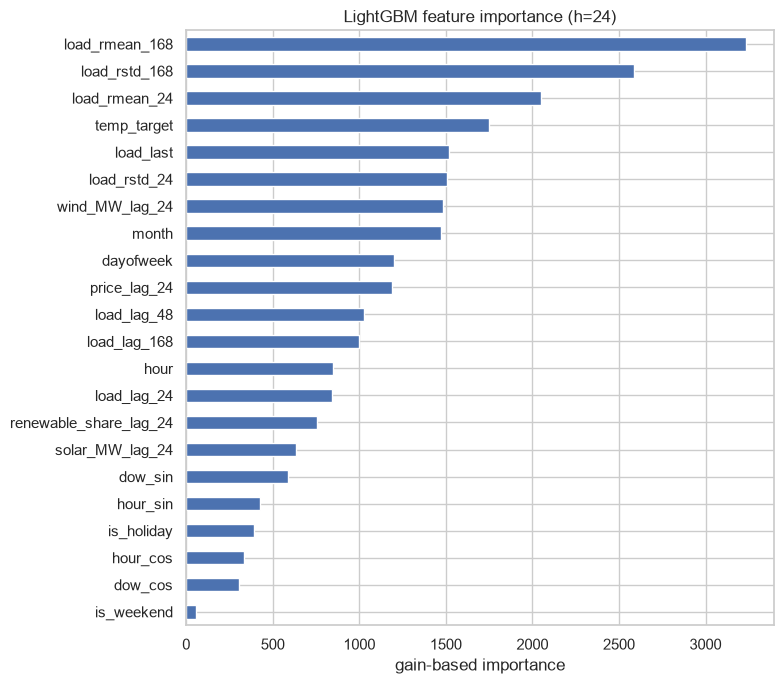

In [6]:
X, y = features.make_supervised(df, horizon=24)
fitted = model.train_lgbm(X, y)
imp = pd.Series(fitted.feature_importances_, index=X.columns).sort_values()
ax = imp.plot.barh(figsize=(8, 7))
ax.set(title="LightGBM feature importance (h=24)", xlabel="gain-based importance")
plt.tight_layout(); plt.show()

## Takeaways

- LightGBM beats the strong seasonal-naive baseline at **every** horizon, with the
  largest gains at short horizons where recent load carries the most signal.
- Remaining error is concentrated where it should be: the daily ramps, holidays and
  temperature extremes.
- The honest evaluation (rolling-origin, baseline-relative, leakage-tested) is what
  makes these numbers trustworthy — see `tests/test_pipeline.py`.